# 02 — Detector de Bolas e Caçapas (Visão Clássica)

Este notebook recebe as imagens normalizadas (top-down) geradas no Módulo 1 e extrai as informações fundamentais da mesa usando técnicas de Visão Computacional Clássica (OpenCV).

**Como funciona:**
1. **Mapeamento:** Define coordenadas fixas para as 6 caçapas baseadas nas margens da imagem.
2. **Segmentação:** Isola o feltro verde da mesa usando o espaço de cores HSV para destacar as bolas.
3. **Separação (Watershed/Distance Transform):** Trata casos complexos onde as bolas estão "coladas" umas nas outras.
4. **Classificação:** Analisa a proporção de pixels brancos dentro de uma máscara circular perfeita para classificar a bola como `branca`, `lisa` ou `listrada`.

**Entrada:** `data/normalized/` (Imagens 800x400 px)  
**Saída:** `data/output/` (Arquivos `.json` com coordenadas e tipos)

In [1]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import glob

## Célula 2 — Função de Classificação de Tipo

Analisa um recorte (ROI) da imagem contendo uma única bola detectada e determina seu tipo com base na quantidade de pixels brancos.
Utilizamos uma máscara circular perfeita para ignorar os cantos do "bounding box" e evitar interferência visual da mesa.

In [2]:
def _classificar_tipo(recorte_hsv, raio):
    h, w = recorte_hsv.shape[:2]
    if h == 0 or w == 0: return "lisa"
    
    # Cria uma máscara circular perfeita do tamanho da bola
    # Isso impede que os cantos do "quadrado" (bounding box) sujem a conta
    mascara_circular = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mascara_circular, (w//2, h//2), int(raio), 255, -1)

    # Conta o tamanho real da bola em pixels
    area_bola = cv2.countNonZero(mascara_circular)
    if area_bola == 0: 
        return "lisa"

    # Threshold de branco recalibrado (mais tolerante a sombras, saturação até 80)
    branco_baixo = np.array([0, 0, 110]) 
    branco_alto  = np.array([180, 80, 255])
    mascara_branca = cv2.inRange(recorte_hsv, branco_baixo, branco_alto)
    
    # Extrai o branco APENAS de dentro do círculo da bola
    branco_na_bola = cv2.bitwise_and(mascara_branca, mascara_branca, mask=mascara_circular)
    pixels_brancos = cv2.countNonZero(branco_na_bola)

    razao = pixels_brancos / float(area_bola)

    # Limiares ajustados para diferenciar melhor Branca, Listrada e Lisa:
    if razao > 0.75:      # Mais de 55% branco = Branca
        return "branca"
    elif razao > 0.18:    # Entre 15% e 54% branco = Listrada
        return "listrada"
    else:                 # Menos de 15% branco = Lisa
        return "lisa"

## Célula 3 — Detecção Principal (Máscaras e Morfologia)

Função responsável por varrer a imagem completa, encontrar as bolas e resolver aglomerados.
Aplica transformações morfológicas (fechar e abrir) com kernels elípticos para focar em objetos redondos.
Se detectar uma área muito grande, aplica "Erosão + Distance Transform" para separar bolas coladas.

In [3]:
def detectar_bolas_e_cacapas(imagem_homografiada):
    resultados = {"cacapas": [], "bolas": []}
    altura, largura = imagem_homografiada.shape[:2]
    
    # 1. MAPEAMENTO DAS CAÇAPAS
    margem_x = int(largura * 0.02)
    margem_y = int(altura * 0.04)
    
    resultados["cacapas"] = [
        {"posicao": "superior_esq",   "x": margem_x,          "y": margem_y},
        {"posicao": "superior_meio",  "x": largura // 2,      "y": margem_y},
        {"posicao": "superior_dir",   "x": largura - margem_x,"y": margem_y},
        {"posicao": "inferior_esq",   "x": margem_x,          "y": altura - margem_y},
        {"posicao": "inferior_meio",  "x": largura // 2,      "y": altura - margem_y},
        {"posicao": "inferior_dir",   "x": largura - margem_x,"y": altura - margem_y}
    ]

    # 2. DETECÇÃO DAS BOLAS
    hsv = cv2.cvtColor(imagem_homografiada, cv2.COLOR_BGR2HSV)
    
    # Máscara do feltro restritiva para não engolir a bola verde ou a preta (Sat > 50, Val > 30)
    verde_baixo = np.array([35, 50, 30]) 
    verde_alto  = np.array([69, 255, 255])
    mascara_mesa  = cv2.inRange(hsv, verde_baixo, verde_alto)
    mascara_bolas = cv2.bitwise_not(mascara_mesa)
    
    # Safe zone (margem de segurança para evitar as sombras dos trilhos)
    safe_zone = np.zeros_like(mascara_bolas)
    margem_seguranca = 15
    cv2.rectangle(safe_zone,
                  (margem_seguranca, margem_seguranca),
                  (largura - margem_seguranca, altura - margem_seguranca),
                  255, -1)
    mascara_bolas = cv2.bitwise_and(mascara_bolas, safe_zone)

    # Kernels elípticos
    kernel_fechar = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernel_abrir  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    
    mascara_limpa = cv2.morphologyEx(mascara_bolas, cv2.MORPH_CLOSE, kernel_fechar)
    mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_OPEN,  kernel_abrir)
    
    contornos, _ = cv2.findContours(mascara_limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    RAIO_MEDIO = 15 # Raio padrão esperado de uma bola na resolução 800x400

    for contorno in contornos:
        area = cv2.contourArea(contorno)
        
        # Ignora poeiras e ruídos
        if area < 60:
            continue

        x, y, w, h = cv2.boundingRect(contorno)
        
        # === SOLUÇÃO PARA BOLAS COLADAS (Watershed / Distance Transform) ===
        if area > 450 or w > 1.5 * RAIO_MEDIO or h > 1.5 * RAIO_MEDIO:
            roi_mask = mascara_limpa[y:y+h, x:x+w]

            # Emagrece a máscara localmente para quebrar a ponte grossa 
            kernel_erode = np.ones((3, 3), np.uint8)
            roi_mask_erodida = cv2.erode(roi_mask, kernel_erode, iterations=1)
            
            # Aplica Transformada de Distância
            dist_transform = cv2.distanceTransform(roi_mask_erodida, cv2.DIST_L2, 3)
            _, picos = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
            picos = np.uint8(picos)

            # Dilata os picos isolados para evitar bolas duplicadas
            kernel_dilate = np.ones((5, 5), np.uint8)
            picos = cv2.dilate(picos, kernel_dilate, iterations=1)
            
            contornos_picos, _ = cv2.findContours(picos, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            for cp in contornos_picos:
                px, py, pw, ph = cv2.boundingRect(cp)
                cx = px + (pw // 2) + x
                cy = py + (ph // 2) + y
                
                y_inicio, y_fim = max(0, cy - RAIO_MEDIO), min(altura, cy + RAIO_MEDIO)
                x_inicio, x_fim = max(0, cx - RAIO_MEDIO), min(largura, cx + RAIO_MEDIO)
                recorte_bola = hsv[y_inicio:y_fim, x_inicio:x_fim]
                
                tipo = _classificar_tipo(recorte_bola, RAIO_MEDIO)
                resultados["bolas"].append({
                    "tipo": tipo, "x": cx, "y": cy, "raio": RAIO_MEDIO
                })
            continue

        # === SOLUÇÃO PARA BOLA INDIVIDUAL ===
        proporcao = float(w) / h
        if 0.5 < proporcao < 2.0 and area <= 1000:
            M = cv2.moments(contorno)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                raio = int((w + h) / 4)
                
                y_inicio, y_fim = max(0, y), min(altura, y+h)
                x_inicio, x_fim = max(0, x), min(largura, x+w)
                recorte_bola = hsv[y_inicio:y_fim, x_inicio:x_fim]
                
                tipo = _classificar_tipo(recorte_bola, raio)
                
                resultados["bolas"].append({
                    "tipo": tipo,
                    "x":    cx,
                    "y":    cy,
                    "raio": int(raio)
                })
                
    return resultados

## Célula 4 — Execução, Visualização e Salvamento

Altere `nome_ficheiro` para a imagem que deseja processar.
Esta célula executa o pipeline, desenha anotações visuais sobre uma cópia da imagem e salva o vetor de coordenadas na pasta `output`.

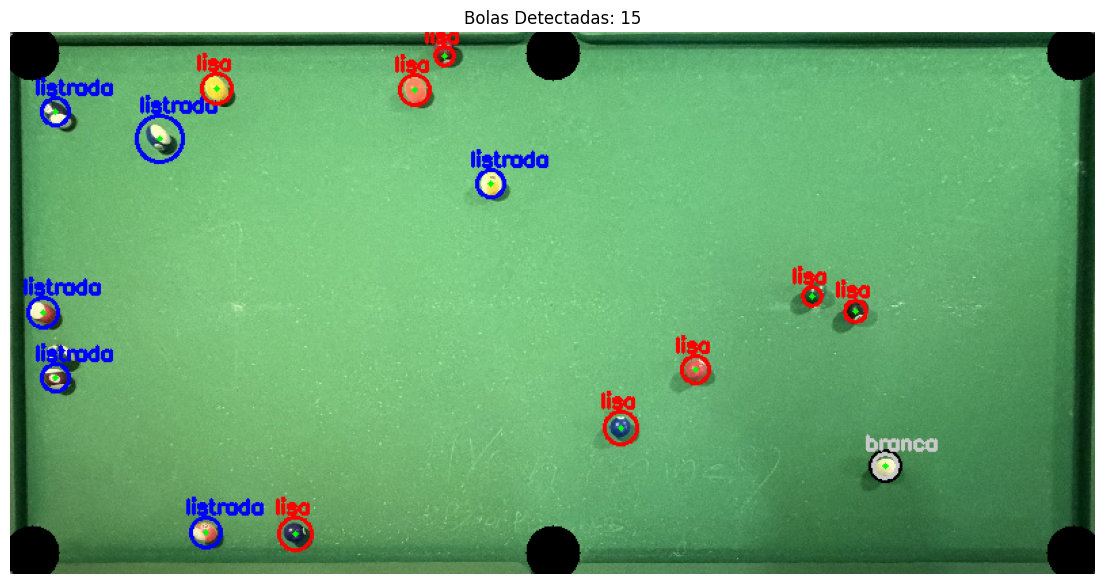

Resultados salvos: /home/juliana/Projects/UFSC/visao/SinucaVision/data/output/IMG_0640/IMG_0640_balls.json


In [4]:
# Configuração de caminhos relativos
CAMINHO_BASE       = os.path.join(os.path.dirname(os.getcwd()), 'data')
CAMINHO_NORMALIZED = os.path.join(CAMINHO_BASE, 'normalized')
CAMINHO_OUTPUT     = os.path.join(CAMINHO_BASE, 'output')

# Defina a imagem a ser processada
nome_ficheiro = 'IMG_0640.JPG'
nome_base     = os.path.splitext(nome_ficheiro)[0]
imagem_path   = os.path.join(CAMINHO_NORMALIZED, nome_ficheiro)
imagem        = cv2.imread(imagem_path)

if imagem is not None:
    dados = detectar_bolas_e_cacapas(imagem)
    imagem_resultado = imagem.copy()

    for cacapa in dados['cacapas']:
        cv2.circle(imagem_resultado, (cacapa['x'], cacapa['y']), 20, (0, 0, 0), -1)

    for bola in dados['bolas']:
        cx, cy, raio = bola['x'], bola['y'], bola['raio']
        tipo = bola['tipo']
        if tipo == 'branca':
            cor = (200, 200, 200)
            cv2.circle(imagem_resultado, (cx, cy), raio + 4, (0, 0, 0), 2)
        elif tipo == 'listrada':
            cor = (255, 0, 0)
        else:
            cor = (0, 0, 255)
        cv2.circle(imagem_resultado, (cx, cy), raio + 2, cor, 2)
        cv2.circle(imagem_resultado, (cx, cy), 2, (0, 255, 0), -1)
        cv2.putText(imagem_resultado, tipo, (cx - 15, cy - raio - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 2)

    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(imagem_resultado, cv2.COLOR_BGR2RGB))
    plt.title(f"Bolas Detectadas: {len(dados['bolas'])}")
    plt.axis('off')
    plt.show()

    # Salva na subpasta da imagem (mesmo padrão do batch)
    pasta = os.path.join(CAMINHO_OUTPUT, nome_base)
    os.makedirs(pasta, exist_ok=True)
    caminho_json = os.path.join(pasta, f'{nome_base}_balls.json')
    with open(caminho_json, 'w', encoding='utf-8') as f:
        json.dump(dados, f, indent=4, ensure_ascii=False)
    print(f"Resultados salvos: {caminho_json}")

else:
    print(f'Erro: imagem não encontrada em {imagem_path}')


## Célula 5 — Processamento em Lote (Batch)

Processa **todas** as imagens em `data/normalized/` de uma vez.  
Para cada imagem gera um arquivo `<nome>_balls.json` em `data/output/`.  
Imagens já processadas são sobrescritas (comportamento idempotente).

In [5]:
import glob

CAMINHO_BASE        = os.path.join(os.path.dirname(os.getcwd()), 'data')
CAMINHO_NORMALIZED  = os.path.join(CAMINHO_BASE, 'normalized')
CAMINHO_OUTPUT      = os.path.join(CAMINHO_BASE, 'output')

imagens = sorted(glob.glob(os.path.join(CAMINHO_NORMALIZED, '*.JPG')))
imagens += sorted(glob.glob(os.path.join(CAMINHO_NORMALIZED, '*.jpg')))
print(f'Imagens encontradas: {len(imagens)}')

for imagem_path in imagens:
    nome_ficheiro = os.path.basename(imagem_path)
    nome_base     = os.path.splitext(nome_ficheiro)[0]
    imagem = cv2.imread(imagem_path)
    if imagem is None:
        print(f'  [ERRO] Não foi possível carregar {nome_ficheiro}')
        continue

    dados  = detectar_bolas_e_cacapas(imagem)
    n_bolas = len(dados['bolas'])
    tipos   = {t: sum(1 for b in dados['bolas'] if b['tipo'] == t)
               for t in ['branca', 'lisa', 'listrada']}

    # Salva JSON direto na subpasta da imagem
    pasta = os.path.join(CAMINHO_OUTPUT, nome_base)
    os.makedirs(pasta, exist_ok=True)
    caminho_json = os.path.join(pasta, f'{nome_base}_balls.json')
    with open(caminho_json, 'w', encoding='utf-8') as f:
        json.dump(dados, f, indent=4, ensure_ascii=False)

    status = '✓' if tipos['branca'] == 1 else '⚠ sem branca'
    print(f'  {status}  {nome_ficheiro}: {n_bolas} bolas '
          f'(branca={tipos["branca"]}, lisas={tipos["lisa"]}, listradas={tipos["listrada"]})')

print(f'\nConcluído: {len(imagens)} imagens → JSONs em data/output/<nome>/')


Imagens encontradas: 6
  ✓  IMG_0640.JPG: 15 bolas (branca=1, lisas=8, listradas=6)
  ✓  IMG_0641.JPG: 18 bolas (branca=1, lisas=9, listradas=8)
  ✓  IMG_0642.JPG: 15 bolas (branca=1, lisas=8, listradas=6)
  ⚠ sem branca  IMG_0643.JPG: 14 bolas (branca=0, lisas=6, listradas=8)
  ⚠ sem branca  IMG_0644.JPG: 14 bolas (branca=0, lisas=6, listradas=8)
  ✓  IMG_0645.JPG: 25 bolas (branca=1, lisas=13, listradas=11)

Concluído: 6 imagens → JSONs em data/output/<nome>/


## Célula 6 — Visualização em Lote

Para cada imagem já processada, cria `data/output/<nome>/` com:
- `<nome>_balls.json` — cópia do JSON de detecção
- `<nome>_viz.png` — imagem anotada + legenda textual com coordenadas de cada bola

In [6]:
import glob
CAMINHO_BASE       = os.path.join(os.path.dirname(os.getcwd()), 'data')
CAMINHO_NORMALIZED = os.path.join(CAMINHO_BASE, 'normalized')
CAMINHO_OUTPUT     = os.path.join(CAMINHO_BASE, 'output')

COR_TIPO = {
    'branca':   (240, 240, 240),
    'lisa':     (255, 165,   0),
    'listrada': ( 80, 160, 255),
}

arquivos_json = sorted(glob.glob(
    os.path.join(CAMINHO_OUTPUT, '**', '*_balls.json'), recursive=True))
print(f'JSONs encontrados: {len(arquivos_json)}')

for caminho_json in arquivos_json:
    nome_base   = os.path.basename(caminho_json).replace('_balls.json', '')
    pasta_saida = os.path.dirname(caminho_json)  # já é a subpasta correta

    # Copia JSON para a subpasta

    # Carrega imagem normalizada (tenta .JPG e .jpg)
    caminho_img = os.path.join(CAMINHO_NORMALIZED, nome_base + '.JPG')
    if not os.path.exists(caminho_img):
        caminho_img = os.path.join(CAMINHO_NORMALIZED, nome_base + '.jpg')
    imagem = cv2.imread(caminho_img)
    if imagem is None:
        print(f'  [ERRO] Imagem não encontrada: {caminho_img}')
        continue

    with open(caminho_json, 'r') as f:
        dados = json.load(f)

    bolas = dados['bolas']
    n_b = sum(1 for b in bolas if b['tipo'] == 'branca')
    n_l = sum(1 for b in bolas if b['tipo'] == 'lisa')
    n_s = sum(1 for b in bolas if b['tipo'] == 'listrada')

    # --- Anotação na imagem ---
    vis = cv2.cvtColor(imagem.copy(), cv2.COLOR_BGR2RGB)
    for cacapa in dados['cacapas']:
        cv2.circle(vis, (cacapa['x'], cacapa['y']), 12, (30, 30, 30), -1)
        cv2.circle(vis, (cacapa['x'], cacapa['y']), 12, (180, 180, 180), 2)

    for idx, bola in enumerate(bolas, 1):
        cx, cy = bola['x'], bola['y']
        raio   = bola.get('raio', 15)
        cor    = COR_TIPO.get(bola['tipo'], (200, 200, 200))
        cv2.circle(vis, (cx, cy), raio + 3, cor, 2)
        cv2.putText(vis, str(idx), (cx - 5, cy - raio - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, cor, 1, cv2.LINE_AA)

    # --- Legenda textual ---
    aviso = '' if n_b == 1 else '  ⚠ BRANCA NÃO DETECTADA'
    cabecalho = (
        f'{nome_base}  |  {len(bolas)} bolas'
        f'  (branca={n_b}  lisas={n_l}  listradas={n_s}){aviso}'
    )
    linhas = [cabecalho, '']

    # Agrupa por tipo para facilitar leitura
    for tipo_label, tipo_key in [('BRANCA', 'branca'), ('LISAS', 'lisa'), ('LISTRADAS', 'listrada')]:
        grupo = [(i, b) for i, b in enumerate(bolas, 1) if b['tipo'] == tipo_key]
        if not grupo:
            continue
        linhas.append(f'  {tipo_label} ({len(grupo)})')
        # Duas colunas para listas longas
        col_esq = grupo[:len(grupo)//2 + len(grupo)%2]
        col_dir = grupo[len(grupo)//2 + len(grupo)%2:]
        for row in range(max(len(col_esq), len(col_dir))):
            def fmt(item):
                i, b = item
                return f'    #{i:>2}  x={b["x"]:>4}  y={b["y"]:>4}'
            esq = fmt(col_esq[row]) if row < len(col_esq) else ''
            dir_ = fmt(col_dir[row]) if row < len(col_dir) else ''
            linhas.append(f'{esq:<34}{dir_}')
        linhas.append('')

    texto = '\n'.join(linhas)

    # --- Figura: imagem em cima, legenda embaixo ---
    n_linhas_texto = len(linhas)
    fig, (ax_img, ax_txt) = plt.subplots(
        2, 1,
        figsize=(12, 6 + n_linhas_texto * 0.22),
        gridspec_kw={'height_ratios': [5, max(1, n_linhas_texto * 0.22)]}
    )

    ax_img.imshow(vis)
    ax_img.set_title(
        f'{nome_base}   branca={n_b}  lisas={n_l}  listradas={n_s}',
        fontsize=12, pad=6
    )
    ax_img.axis('off')

    ax_txt.axis('off')
    ax_txt.text(
        0.01, 0.99, texto,
        transform=ax_txt.transAxes,
        fontsize=8.5, fontfamily='monospace',
        verticalalignment='top'
    )

    plt.tight_layout()
    caminho_viz = os.path.join(pasta_saida, f'{nome_base}_viz.png')
    plt.savefig(caminho_viz, dpi=130, bbox_inches='tight')
    plt.close()

    print(f'  ✓  {nome_base}/ → _viz.png  ({len(bolas)} bolas: {n_b}B {n_l}L {n_s}S)')

print(f'\nVisualizações salvas em data/output/<nome>/')

JSONs encontrados: 6


  ✓  IMG_0640/ → _viz.png  (15 bolas: 1B 8L 6S)


  ✓  IMG_0641/ → _viz.png  (18 bolas: 1B 9L 8S)


  ✓  IMG_0642/ → _viz.png  (15 bolas: 1B 8L 6S)


  ✓  IMG_0643/ → _viz.png  (14 bolas: 0B 6L 8S)


  ✓  IMG_0644/ → _viz.png  (14 bolas: 0B 6L 8S)


  ✓  IMG_0645/ → _viz.png  (25 bolas: 1B 13L 11S)

Visualizações salvas em data/output/<nome>/
